# Popensity Score Matching: Estimación del efecto causal de ser o no fumador sobre el riesgo de padecer una enfermedad coronaria a 10 años.

## Introducción

En este notebook se implementa la metodología **Propensity Score Matching (PSM)** con el objetivo de estimar el efecto del hábito de fumar sobre la probabilidad de desarrollar una enfermedad coronaria en los diez años posteriores al estudio.

Para ello se emplea el conjunto de datos **Framingham Heart Study Dataset**, un estudio observacional ampliamente utilizado en epidemiología cardiovascular, llevado a cabo en Framingham, Massachusetts. 

La pregunta causal que se pretende responder es:

> **¿Qué efecto tiene el hábito de fumar sobre el riesgo de desarrollar una enfermedad coronaria a 10 años?** 


## 1. Importación de librerías
A diferencia del notebook anterior, en este trabajaremos con el software estadístico $R$.
En este apartado se cargan las librerías necesarias para la manipulación de datos, la implementación del algoritmo Propensity Score Matching y la representación gráfica de los resultados.

In [106]:
# Instalación de paquetes (solo la primera vez)
#install.packages("tidyverse")
#install.packages("MatchIt", type="binary")
#install.packages("cobalt")
#install.packages("tableone", type="binary")
#install.packages("vctrs", table="binary")


In [3]:
# Carga de librerías

# Manipulación y visualización de datos
library(tidyverse)

# Implementación del algoritmo Propensity Score Matching
library(MatchIt)

# Evaluación del balance de covariables
library(cobalt)

# Tabla resumen
library(tableone)



## 2. Carga del conjunto de datos

Se carga el conjunto de datos correspondiente al estudio Framingham Heart Study.

In [4]:
# Carga del conjunto de datos
df <- read.csv("framingham_heart_study.csv")


In [5]:
# Visualización de las primeras observaciones
head(df)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
1,1,39,4,0,0,0,0,0,0,195,106.0,70,26.97,80,77,0
2,0,46,2,0,0,0,0,0,0,250,121.0,81,28.73,95,76,0
3,1,48,1,1,20,0,0,0,0,245,127.5,80,25.34,75,70,0
4,0,61,3,1,30,0,0,1,0,225,150.0,95,28.58,65,103,1
5,0,46,3,1,23,0,0,0,0,285,130.0,84,23.10,85,85,0
6,0,43,2,0,0,0,0,1,0,228,180.0,110,30.30,77,99,0


## 3.Exploración inicial de los datos.

In [6]:
# Dimensiones del conjunto de datos
dim(df)

[1] 4240   16

In [7]:
# Nombres de las variables
names(df)

[1] "male"            "age"             "education"       "currentSmoker"  
 [5] "cigsPerDay"      "BPMeds"          "prevalentStroke" "prevalentHyp"   
 [9] "diabetes"        "totChol"         "sysBP"           "diaBP"          
[13] "BMI"             "heartRate"       "glucose"         "TenYearCHD"

In [8]:
# Estructura del conjunto de datos
str(df)

'data.frame':	4240 obs. of  16 variables:
 $ male           : int  1 0 1 0 0 0 0 0 1 1 ...
 $ age            : int  39 46 48 61 46 43 63 45 52 43 ...
 $ education      : int  4 2 1 3 3 2 1 2 1 1 ...
 $ currentSmoker  : int  0 0 1 1 1 0 0 1 0 1 ...
 $ cigsPerDay     : int  0 0 20 30 23 0 0 20 0 30 ...
 $ BPMeds         : int  0 0 0 0 0 0 0 0 0 0 ...
 $ prevalentStroke: int  0 0 0 0 0 0 0 0 0 0 ...
 $ prevalentHyp   : int  0 0 0 1 0 1 0 0 1 1 ...
 $ diabetes       : int  0 0 0 0 0 0 0 0 0 0 ...
 $ totChol        : int  195 250 245 225 285 228 205 313 260 225 ...
 $ sysBP          : num  106 121 128 150 130 ...
 $ diaBP          : num  70 81 80 95 84 110 71 71 89 107 ...
 $ BMI            : num  27 28.7 25.3 28.6 23.1 ...
 $ heartRate      : int  80 95 75 65 85 77 60 79 76 93 ...
 $ glucose        : int  77 76 70 103 85 99 85 78 79 88 ...
 $ TenYearCHD     : int  0 0 0 1 0 0 1 0 0 0 ...


In [9]:
# Resumen estadístico de las variables
summary(df)

      male             age          education     currentSmoker   
 Min.   :0.0000   Min.   :32.00   Min.   :1.000   Min.   :0.0000  
 1st Qu.:0.0000   1st Qu.:42.00   1st Qu.:1.000   1st Qu.:0.0000  
 Median :0.0000   Median :49.00   Median :2.000   Median :0.0000  
 Mean   :0.4292   Mean   :49.58   Mean   :1.979   Mean   :0.4941  
 3rd Qu.:1.0000   3rd Qu.:56.00   3rd Qu.:3.000   3rd Qu.:1.0000  
 Max.   :1.0000   Max.   :70.00   Max.   :4.000   Max.   :1.0000  
                                  NA's   :105                     
   cigsPerDay         BPMeds        prevalentStroke     prevalentHyp   
 Min.   : 0.000   Min.   :0.00000   Min.   :0.000000   Min.   :0.0000  
 1st Qu.: 0.000   1st Qu.:0.00000   1st Qu.:0.000000   1st Qu.:0.0000  
 Median : 0.000   Median :0.00000   Median :0.000000   Median :0.0000  
 Mean   : 9.006   Mean   :0.02962   Mean   :0.005896   Mean   :0.3106  
 3rd Qu.:20.000   3rd Qu.:0.00000   3rd Qu.:0.000000   3rd Qu.:1.0000  
 Max.   :70.000   Max.   :1.0000

In [10]:
# Número de valores perdidos por variable
colSums(is.na(df))

male             age       education   currentSmoker      cigsPerDay 
              0               0             105               0              29 
         BPMeds prevalentStroke    prevalentHyp        diabetes         totChol 
             53               0               0               0              50 
          sysBP           diaBP             BMI       heartRate         glucose 
              0               0              19               1             388 
     TenYearCHD 
              0

In [11]:
# Eliminación de observaciones con valores perdidos
df <- na.omit(df)

In [12]:
# Comprobamos nuevamente las dimensiones
dim(df)

[1] 3658   16

## 4. Descripción de las variables

En este estudio se pretende estimar el efecto del hábito de fumar sobre la probabilidad de desarrollar una enfermedad coronaria durante los diez años posteriores al inicio del seguimiento.

Para ello se define una variable de tratamiento, una variable resultado y un conjunto de covariables que se utilizarán posteriormente para estimar el propensity score.

Las variables del dataset corresponden a características demográficas y clínicas:

In [12]:
# Tabla descriptiva de las variables
variables <- data.frame(

  Variable = c(
    "currentSmoker",
    "TenYearCHD",
    "age",
    "education",
    "male",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose",
    "diabetes",
    "prevalentHyp"
  ),

  Descripcion = c(
    "Variable de tratamiento (1 = fumador, 0 = no fumador)",
    "Variable resultado (1 = enfermedad coronaria a 10 años)",
    "Edad del individuo (años)",
    "Nivel educativo del individuo (categorías de 1 a 4)",
    "Sexo (1 = hombre, 0 = mujer)",
    "Colesterol total",
    "Presión arterial sistólica",
    "Presión arterial diastólica",
    "Índice de masa corporal",
    "Frecuencia cardíaca",
    "Nivel de glucosa",
    "Diagnóstico de diabetes",
    "Hipertensión previa"
  ),

  Tipo = c(
    "Binaria",
    "Binaria",
    "Cuantitativa",
    "Categórica",
    "Binaria",
    "Cuantitativa",
    "Cuantitativa",
    "Cuantitativa",
    "Cuantitativa",
    "Cuantitativa",
    "Cuantitativa",
    "Binaria",
    "Binaria"
  )

)

variables

Variable,Descripcion,Tipo
<chr>,<chr>,<chr>
currentSmoker,"Variable de tratamiento (1 = fumador, 0 = no fumador)",Binaria
TenYearCHD,Variable resultado (1 = enfermedad coronaria a 10 años),Binaria
age,Edad del individuo (años),Cuantitativa
education,Nivel educativo del individuo (categorías de 1 a 4),Categórica
male,"Sexo (1 = hombre, 0 = mujer)",Binaria
totChol,Colesterol total,Cuantitativa
sysBP,Presión arterial sistólica,Cuantitativa
diaBP,Presión arterial diastólica,Cuantitativa
BMI,Índice de masa corporal,Cuantitativa


## 5. Definición del problema

Antes de aplicar el algoritmo Propensity Score Matching es necesario preparar el conjunto de datos para el análisis.
En esta etapa se definen explícitamente la variable de tratamiento, la variable resultado y las variables pretratamiento. Además, se comprueba la distribución de las variables tratamiento y resultado para conocer la composición inicial de los grupos que posteriormente serán emparejados.

### 5.1. Definición de la variable de tratamiento

Sea $T_i$ la variable indicadora de tratamiento correspondiente al individuo $i$, definida como

$$
T_i=
\begin{cases}
1, & \text{si el individuo es fumador},\\
0, & \text{si el individuo no es fumador}.
\end{cases}
$$


In [13]:
df$T <- df$currentSmoker

In [14]:
df$T <- as.factor(df$T)

### 5.2. Definición de la variable resultado

Sea $Y_i$ la variable indicadora del resultado correspondiente al individuo $i$, definida como

$$
Y_i=
\begin{cases}
1, & \text{si el individuo padece enfermedad coronaria a 10 años},\\
0, & \text{en caso contrario}.
\end{cases}
$$


In [15]:
df$Y <- df$TenYearCHD

In [16]:
# Matriz de confusión del tratamiento y el resultado
table(df$T, df$Y)

   
       0    1
  0 1597  272
  1 1504  285

Esta tabla es muy interesante, porque ya ofrece una primera visión de cuántos fumadores y no fumadores desarrollan enfermedad coronaria antes de aplicar el matching.

### 5.3. Definición de las variables pretratamiento

Las covariables utilizadas para estimar el propensity score incluyen únicamente variables pretratamiento como edad, sexo y educación así como condiciones de salud previas al inicio del hábito de fumar (hipertensión y diabetes). Se excluyen variables potencialmente afectadas por el tabaquismo, como colesterol, presión arterial o niveles de glucosa, ya que su inclusión podría introducir sesgo al actuar como mediadores del efecto del tratamiento.

## 6. Análisis descriptivo

Antes de estimar el propensity score resulta conveniente comparar las características iniciales de los individuos pertenecientes al grupo de tratamiento y al grupo de control.

Este análisis descriptivo permite identificar posibles diferencias entre ambos grupos antes del proceso de emparejamiento y servirá posteriormente para comprobar si el algoritmo consigue equilibrar las covariables.

In [17]:
# Número de individuos por grupo
table(df$T)


   0    1 
1869 1789 

In [18]:
# Proporción de fumadores y no fumadores
prop.table(table(df$T))


        0         1 
0.5109349 0.4890651 

A continuación se representa gráficamente la distribución de individuos pertenecientes al grupo de tratamiento y al grupo de control.

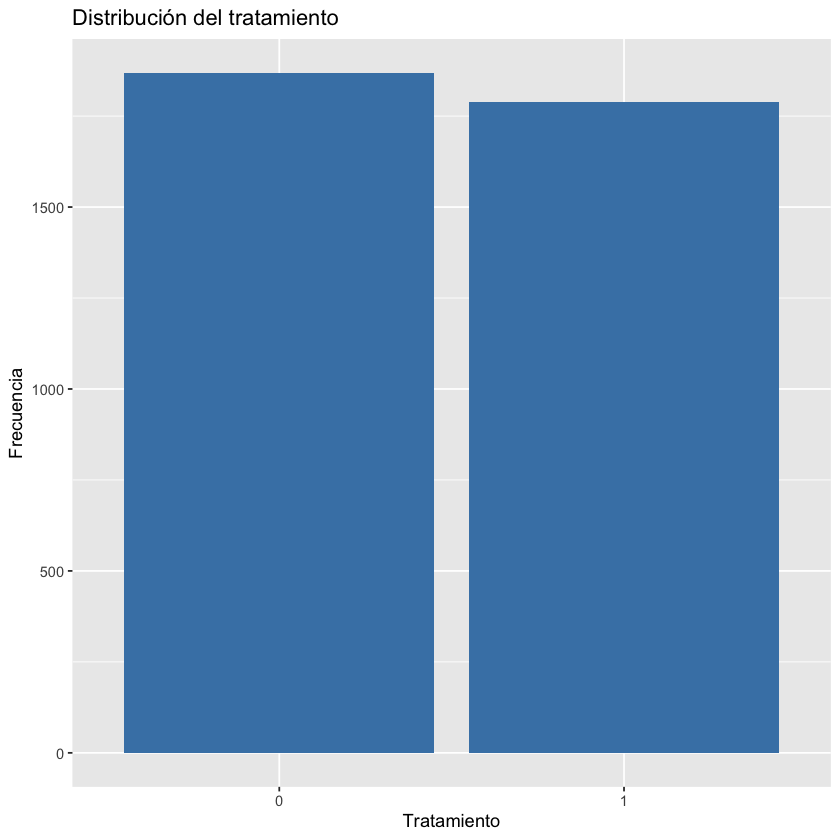

In [19]:
# Distribución del tratamiento

ggplot(df, aes(x = factor(T))) +

geom_bar(fill = "steelblue") +

labs(
  title = "Distribución del tratamiento",
  x = "Tratamiento",
  y = "Frecuencia"
)

In [20]:
# Variables pretratamiento (numéricas y categóricas)

variables <- c(
  "age",
  "male",
  "diabetes",
  "education",
  "prevalentHyp"
)

In [21]:
# Variables categóricas
factores <- c(
  "male",
  "diabetes",
  "education",
  "prevalentHyp"
)


In [22]:
tabla1 <- CreateTableOne(
  vars = variables,
  strata = "T",
  data = df,
  factorVars = factores
)

In [23]:
print(
  tabla1,
  showAllLevels = TRUE,
  quote = FALSE,
  noSpaces = TRUE,
  test = TRUE,
  smd = TRUE
)

                  Stratified by T
                   level 0            1            p      test SMD  
  n                      1869         1789                          
  age (mean (SD))        51.32 (8.72) 47.71 (7.99) <0.001      0.432
  male (%)         0     1227 (65.7)  808 (45.2)   <0.001      0.421
                   1     642 (34.3)   981 (54.8)                    
  diabetes (%)     0     1806 (96.6)  1753 (98.0)  0.015       0.084
                   1     63 (3.4)     36 (2.0)                      
  education (%)    1     824 (44.1)   702 (39.2)   0.001       0.132
                   2     513 (27.4)   588 (32.9)                    
                   3     324 (17.3)   284 (15.9)                    
                   4     208 (11.1)   215 (12.0)                    
  prevalentHyp (%) 0     1195 (63.9)  1323 (74.0)  <0.001      0.218
                   1     674 (36.1)   466 (26.0)                    


## 7. Estimación del Propensity Score

El siguiente paso consiste en estimar la probabilidad de que cada individuo pertenezca al grupo de tratamiento en función de sus características observadas.

Esta probabilidad, denominada *propensity score*, recordemos que se obtiene mediante un modelo de regresión logística en el que la variable dependiente es el tratamiento y las variables independientes corresponden a las covariables seleccionadas previamente.

Posteriormente, estos valores se utilizarán para realizar el proceso de emparejamiento entre individuos tratados y no tratados con características similares.

In [24]:
# Estimación del propensity score mediante regresión logística
modelo_ps <- glm(
  T ~ age +
      male +
      diabetes +
      education +
      prevalentHyp,
  family = binomial(),
  data = df
)

In [25]:
# Resumen del modelo logístico
summary(modelo_ps)


Call:
glm(formula = T ~ age + male + diabetes + education + prevalentHyp, 
    family = binomial(), data = df)

Deviance Residuals: 
   Min      1Q  Median      3Q     Max  
-1.735  -1.093  -0.679   1.119   1.885  

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)   2.088135   0.233763   8.933  < 2e-16 ***
age          -0.048114   0.004379 -10.988  < 2e-16 ***
male          0.867464   0.069929  12.405  < 2e-16 ***
diabetes     -0.285253   0.221824  -1.286  0.19846    
education    -0.028669   0.034251  -0.837  0.40258    
prevalentHyp -0.237212   0.078812  -3.010  0.00261 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 5069.3  on 3657  degrees of freedom
Residual deviance: 4736.8  on 3652  degrees of freedom
AIC: 4748.8

Number of Fisher Scoring iterations: 4


In [26]:
# Cálculo del Propensity Score
df$propensity_score <- predict(
  modelo_ps,
  type = "response"
)

In [27]:
# Primeras observaciones
head(df[, c("T", "propensity_score")])

,T,propensity_score
,<fct>,<dbl>
1,0,0.7240174
2,0,0.4545146
3,1,0.6496403
4,1,0.2368483
5,1,0.4474165
6,0,0.4316024


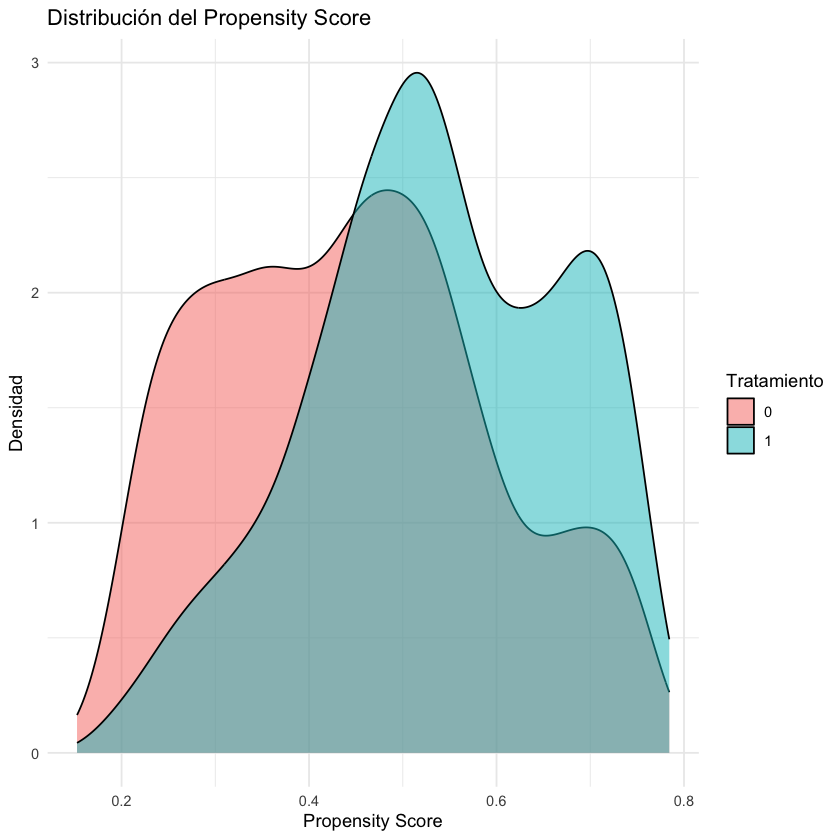

In [28]:
# Distribución del Propensity Score
library(ggplot2)

ggplot(df,
       aes(x = propensity_score,
           fill = T)) +
geom_density(alpha = 0.5) +

labs(
  title = "Distribución del Propensity Score",
  x = "Propensity Score",
  y = "Densidad",
  fill = "Tratamiento"
) +

theme_minimal()

## 9. Aplicación del Propensity Score Matching

Una vez estimado el propensity score, se procede a emparejar los individuos tratados y de control mediante el algoritmo *Nearest Neighbor Matching*.

Recordemmos que el objetivo es obtener dos grupos comparables respecto a las covariables observadas, reduciendo así el sesgo de selección presente en los datos originales.

In [29]:
# Aplicación del Propensity Score Matching

matching <- matchit(
  T ~ age +
    male +
    education +
    prevalentHyp +
    diabetes,
  data = df,
  method = "nearest",
  distance = "logit"
)

## 10. Evaluación del emparejamiento

Una vez realizado el proceso de emparejamiento mediante Propensity Score Matching, es necesario comprobar si el balance entre el grupo de tratamiento y el grupo de control ha mejorado.

Para ello se analizarán las medidas de balance antes y después del matching.

In [30]:
# Resumen del proceso de emparejamiento
summary(matching)


Call:
matchit(formula = T ~ age + male + education + prevalentHyp + 
    diabetes, data = df, method = "nearest", distance = "logit")

Summary of Balance for All Data:
             Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance            0.5340        0.4461          0.6504     0.8410    0.1659
age                47.7077       51.3173         -0.4515     0.8412    0.0926
male                0.5484        0.3435          0.4116          .    0.2049
education           2.0067        1.9551          0.0508     0.9759    0.0158
prevalentHyp        0.2605        0.3606         -0.2282          .    0.1001
diabetes            0.0201        0.0337         -0.0967          .    0.0136
             eCDF Max
distance       0.2579
age            0.2059
male           0.2049
education      0.0485
prevalentHyp   0.1001
diabetes       0.0136

Summary of Balance for Matched Data:
             Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance       

In [31]:
# Extracción de la muestra emparejada
df_match <- match.data(matching)

In [32]:
# Dimensiones de la muestra emparejada
dim(df_match)

[1] 3578   22

Así comprobamos cuántos individuos han permanecido tras el matching.

## 11. Balance de covariables tras el emparejamiento

Una vez obtenida la muestra emparejada, se vuelve a realizar el análisis descriptivo con el objetivo de comprobar si las diferencias iniciales entre ambos grupos se han reducido.

In [33]:
tabla_match <- CreateTableOne(
  vars = variables,
  strata = "T",
  data = df_match,
  factorVars = factores
)

In [34]:
print(
  tabla_match,
  showAllLevels = TRUE,
  test = TRUE,
  smd = TRUE,
  quote = FALSE,
  noSpaces = TRUE
)

                  Stratified by T
                   level 0            1            p      test SMD  
  n                      1789         1789                          
  age (mean (SD))        50.73 (8.43) 47.71 (7.99) <0.001      0.368
  male (%)         0     1147 (64.1)  808 (45.2)   <0.001      0.388
                   1     642 (35.9)   981 (54.8)                    
  diabetes (%)     0     1736 (97.0)  1753 (98.0)  0.086       0.061
                   1     53 (3.0)     36 (2.0)                      
  education (%)    1     774 (43.3)   702 (39.2)   0.004       0.122
                   2     495 (27.7)   588 (32.9)                    
                   3     314 (17.6)   284 (15.9)                    
                   4     206 (11.5)   215 (12.0)                    
  prevalentHyp (%) 0     1194 (66.7)  1323 (74.0)  <0.001      0.158
                   1     595 (33.3)   466 (26.0)                    


## 12. Evaluación gráfica del balance

Además de la comparación mediante tablas descriptivas, resulta conveniente representar gráficamente el equilibrio de las covariables antes y después del emparejamiento.

Para ello se emplea un **Love Plot**, que muestra la Diferencia de Medias Estandarizada (SMD) para cada covariable antes y después del matching.

Un buen emparejamiento se refleja en una disminución de las SMD, idealmente por debajo del umbral de 0.1.

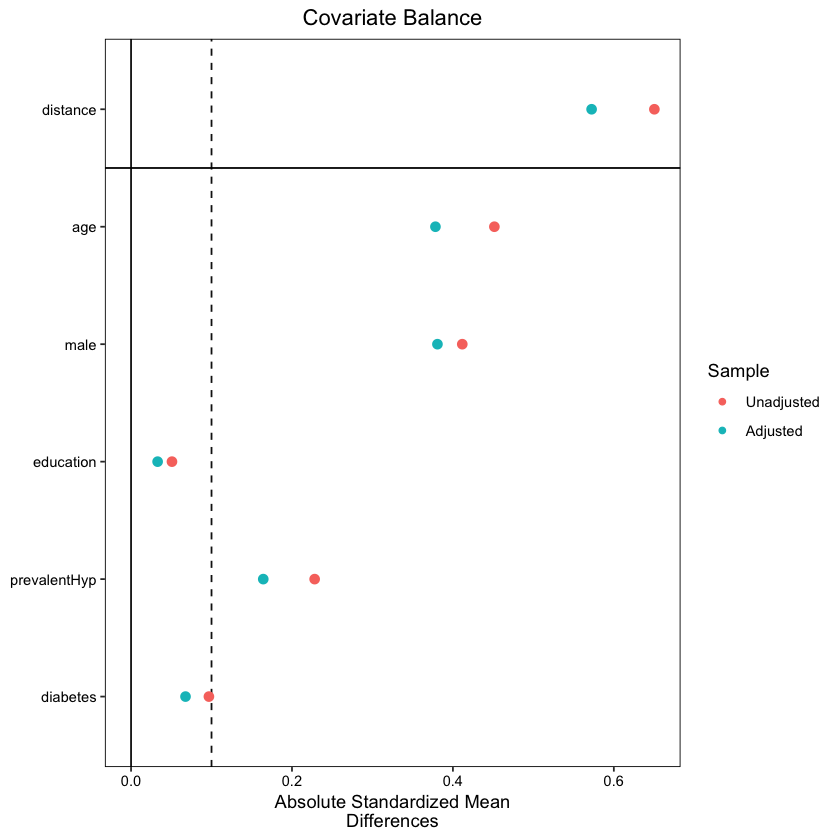

In [35]:
# Love Plot
love.plot(
  matching,
  binary = "std",
  threshold = 0.1,
  abs = TRUE,
  stars = "raw"
)

In [36]:
# Comparación de las SMD antes y después del matching
# Extraemos el balance del objeto MatchIt
balance <- summary(matching)$sum.all
balance_match <- summary(matching)$sum.matched

# Creamos una tabla resumen
tabla_balance <- data.frame(
  Variable = rownames(balance),
  SMD_Antes = round(abs(balance[, "Std. Mean Diff."]), 3),
  SMD_Despues = round(abs(balance_match[, "Std. Mean Diff."]), 3)
)

# Eliminamos los nombres de fila
rownames(tabla_balance) <- NULL

# Mostramos la tabla
tabla_balance

Variable,SMD_Antes,SMD_Despues
<chr>,<dbl>,<dbl>
distance,0.650,0.572
age,0.452,0.378
male,0.412,0.381
education,0.051,0.033
prevalentHyp,0.228,0.164
diabetes,0.097,0.068


In [37]:
# Tabla resumen del balance de covariables
balance <- summary(matching)$sum.all
balance_match <- summary(matching)$sum.matched

tabla_balance <- data.frame(
  Variable = rownames(balance),
  SMD_Antes = round(abs(balance[, "Std. Mean Diff."]), 3),
  SMD_Despues = round(abs(balance_match[, "Std. Mean Diff."]), 3)
)

tabla_balance$Balance_Adecuado <- ifelse(
  tabla_balance$SMD_Despues < 0.1,
  "Sí",
  "No"
)

rownames(tabla_balance) <- NULL

tabla_balance

Variable,SMD_Antes,SMD_Despues,Balance_Adecuado
<chr>,<dbl>,<dbl>,<chr>
distance,0.650,0.572,No
age,0.452,0.378,No
male,0.412,0.381,No
education,0.051,0.033,Sí
prevalentHyp,0.228,0.164,No
diabetes,0.097,0.068,Sí


## 13. Matching introduciendo caliper en el modelo

Se utiliza un emparejamiento por vecino más cercano con un caliper de 0,2. Este criterio limita la distancia máxima permitida entre los propensity scores de los individuos emparejados, evitando comparaciones entre sujetos con características muy diferentes y mejorando así la calidad del emparejamiento. Como consecuencia, algunos individuos que no encontraron una pareja suficientemente similar fueron excluidos del análisis.

In [38]:
matching <- matchit(
  T ~ age +
    male +
    education +
    prevalentHyp +
    diabetes,
  data = df,
  method = "nearest",
  distance = "logit",
  caliper = 0.2
)

In [39]:
summary(matching)


Call:
matchit(formula = T ~ age + male + education + prevalentHyp + 
    diabetes, data = df, method = "nearest", distance = "logit", 
    caliper = 0.2)

Summary of Balance for All Data:
             Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance            0.5340        0.4461          0.6504     0.8410    0.1659
age                47.7077       51.3173         -0.4515     0.8412    0.0926
male                0.5484        0.3435          0.4116          .    0.2049
education           2.0067        1.9551          0.0508     0.9759    0.0158
prevalentHyp        0.2605        0.3606         -0.2282          .    0.1001
diabetes            0.0201        0.0337         -0.0967          .    0.0136
             eCDF Max
distance       0.2579
age            0.2059
male           0.2049
education      0.0485
prevalentHyp   0.1001
diabetes       0.0136

Summary of Balance for Matched Data:
             Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF 

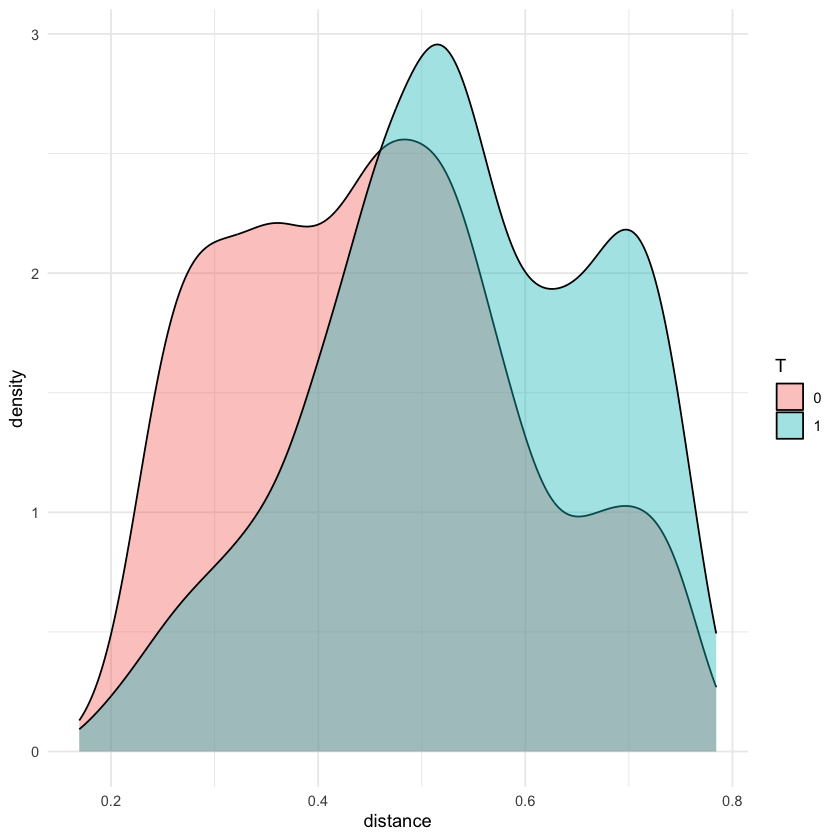

In [40]:
ggplot(df_match,
       aes(distance,
           fill = T)) +
  geom_density(alpha = 0.4) +
  theme_minimal()

In [41]:
# Extracción de la muestra emparejada
df_match <- match.data(matching)

In [42]:
# Dimensiones de la muestra emparejada
dim(df_match)

[1] 2962   22

In [43]:
# Comparación de las SMD antes y después del matching
# Extraemos el balance del objeto MatchIt
balance <- summary(matching)$sum.all
balance_match <- summary(matching)$sum.matched

# Creamos una tabla resumen
tabla_balance <- data.frame(
  Variable = rownames(balance),
  SMD_Antes = round(abs(balance[, "Std. Mean Diff."]), 3),
  SMD_Despues = round(abs(balance_match[, "Std. Mean Diff."]), 3)
)

# Eliminamos los nombres de fila
rownames(tabla_balance) <- NULL

# Mostramos la tabla
tabla_balance

Variable,SMD_Antes,SMD_Despues
<chr>,<dbl>,<dbl>
distance,0.650,0.154
age,0.452,0.096
male,0.412,0.128
education,0.051,0.071
prevalentHyp,0.228,0.034
diabetes,0.097,0.038


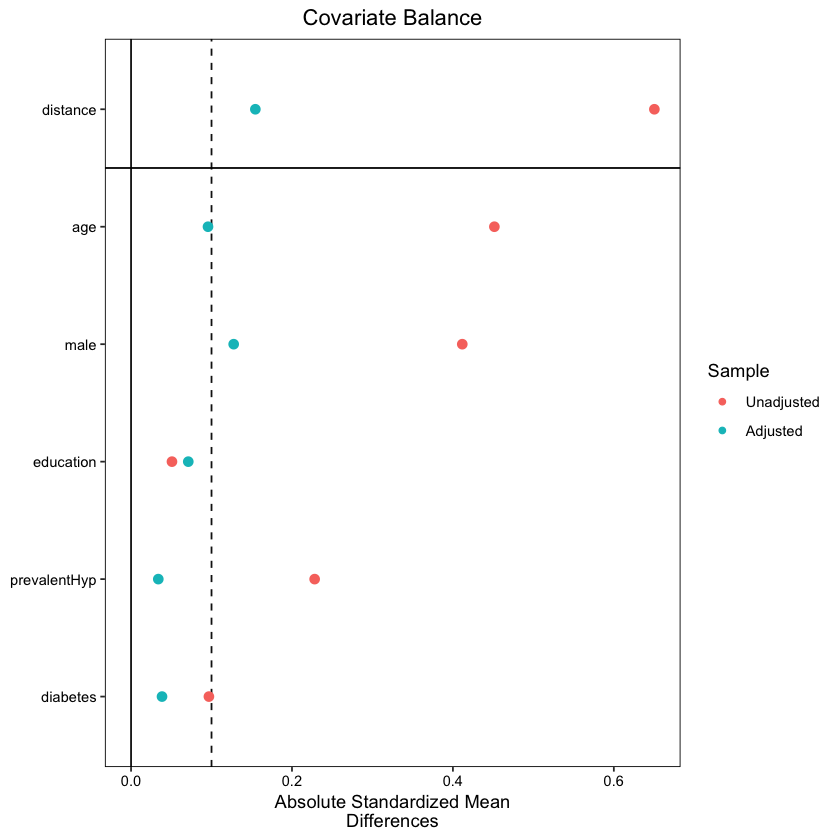

In [44]:

love.plot(
  matching,
  binary = "std",
  threshold = 0.1,
  abs = TRUE,
  stars = "raw"
)


## 14. Estimación del efecto del tratamiento tras el emparejamiento

Una vez comprobado que el procedimiento de emparejamiento ha mejorado el equilibrio entre las covariables de los grupos tratado y de control, se procede a estimar el efecto causal del tratamiento sobre la variable resultado utilizando la muestra emparejada.

En primer lugar, se extrae la muestra resultante del proceso de emparejamiento. Posteriormente, se compara la incidencia de enfermedad coronaria a 10 años entre fumadores y no fumadores, obteniendo una estimación del efecto medio del tratamiento sobre los tratados (ATT).

In [45]:
# Extraer la muestra emparejada
df_match <- match.data(matching)

In [46]:
# Número de individuos por grupo
table(df_match$T)


   0    1 
1481 1481 

In [47]:
# Proporción de enfermedad coronaria en cada grupo
prop.table(table(df_match$T, df_match$TenYearCHD), margin = 1)

   
            0         1
  0 0.8777853 0.1222147
  1 0.8365969 0.1634031

In [48]:
# Estimación del ATT (diferencia de proporciones)
ATT <- with(df_match,
            mean(TenYearCHD[T == 1]) -
            mean(TenYearCHD[T == 0]))

ATT

[1] 0.04118839

In [49]:
# Contraste de hipótesis
t.test(TenYearCHD ~ T, data = df_match)


	Welch Two Sample t-test

data:  TenYearCHD by T
t = -3.208, df = 2917.6, p-value = 0.001351
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -0.06636372 -0.01601305
sample estimates:
mean in group 0 mean in group 1 
      0.1222147       0.1634031 


In [50]:
# Estimación del ATT
ATT <- with(df_match,
            mean(TenYearCHD[T == 1]) -
            mean(TenYearCHD[T == 0]))

# Test t
tt <- t.test(TenYearCHD ~ T, data = df_match)

# Tabla resumen
tabla_att <- data.frame(
  Medida = c(
    "Media grupo tratado",
    "Media grupo control",
    "ATT estimado",
    "Estadístico t",
    "p-valor",
    "IC 95% inferior",
    "IC 95% superior"
  ),
  Valor = c(
    tt$estimate[2],
    tt$estimate[1],
    ATT,
    tt$statistic,
    tt$p.value,
    tt$conf.int[1],
    tt$conf.int[2]
  )
)

tabla_att

Medida,Valor
<chr>,<dbl>
Media grupo tratado,0.163403106
Media grupo control,0.122214720
ATT estimado,0.041188386
Estadístico t,-3.207951525
p-valor,0.001351312
IC 95% inferior,-0.066363722
IC 95% superior,-0.016013050


**Interpretación del efecto estimado**

El ATT obtenido representa la diferencia en la probabilidad de desarrollar una enfermedad coronaria a 10 años entre los individuos fumadores y los no fumadores, una vez que ambos grupos han sido equilibrados respecto a las covariables consideradas mediante Propensity Score Matching.

Como el p-valor es inferior a 0,05, se concluye que existe evidencia estadísticamente significativa de un efecto del tabaquismo sobre el riesgo de enfermedad coronaria a 10 años.